## Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import importlib

import sys
sys.path.append("../../")
import methods  
importlib.reload(methods)


Error importing in API mode: ImportError("dlopen(/Users/timothysudijono/anaconda3/envs/eb/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /usr/lib/libpcre2-8.0.dylib\n  Referenced from: <20FB70DB-7E84-3375-A520-E0350E06C060> /Users/timothysudijono/anaconda3/envs/eb/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/usr/lib/libpcre2-8.0.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/lib/libpcre2-8.0.dylib' (no such file), '/usr/lib/libpcre2-8.0.dylib' (no such file, not in dyld cache)")
Trying to import in ABI mode.


<module 'methods' from '/Users/timothysudijono/Projects/statistics/empirical_bayes/CompoundWelfareMaximization/empirical_analyses/exp/../../methods.py'>

In [19]:
def visualize(df, threshold = 1.96):
    fig, ax = plt.subplots(1,3, figsize = (12,3))
    ax[0].scatter(df["treatment_effects"], df["standard_errors"], s = 10)
    ax[0].set_xlabel("Treatment Effects")
    ax[0].set_ylabel("Standard Errors")
    ax[0].set_title("TEs vs Std. Errors")

    tstat_threshold = threshold

    mask = (df["tstats"] > tstat_threshold)
    masked_df = df.loc[mask,:]
    ax[0].scatter(masked_df["treatment_effects"],
                masked_df["standard_errors"],
                s = 10, color = "orange")

    xs = np.linspace(-0.3,0.3)
    ax[0].plot(xs, xs/tstat_threshold,color = "orange", linestyle = "dashed")
    ax[0].set_ylim(0,0.10)

    ax[1].hist(df["treatment_effects"], bins = 50)
    ax[1].set_xlabel("$Y_i$")
    ax[1].set_ylabel("Counts")
    ax[1].set_title("TE Histogram")


    ax[2].hist((df["standard_errors"]), bins = 50)
    ax[2].set_xlabel("$\sigma_i$")
    ax[2].set_ylabel("Counts")
    ax[2].set_title("SE Histogram")

    #print(df["treatment_effects"].describe())
    #print(df["tstats"].describe())

In [20]:
df = pd.read_csv("data/example_te_data.csv").iloc[:,1:]
df["tstats"] = df["treatment_effects"]/df["standard_errors"]
df.head(10)
print(df.shape)

(331, 3)


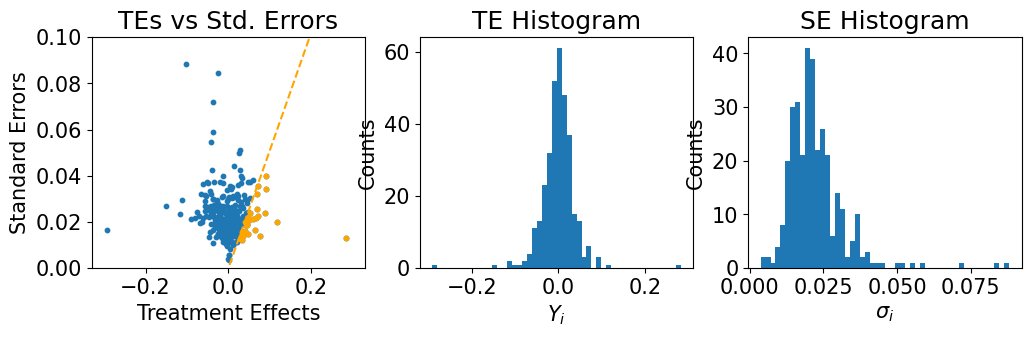

In [21]:
visualize(df)
plt.savefig("experimentation_program_viz.pdf", bbox_inches = 'tight')

In [22]:
median_treatment_effect = np.median(np.abs(df["treatment_effects"]))

In [23]:
from statistics import NormalDist

Ys = np.array(df["treatment_effects"])
sigmas = np.array(df["standard_errors"])

mask = (sigmas < 0.045)
Ys = Ys[mask]
sigmas = sigmas[mask]

costs = np.zeros(len(Ys))
grid = np.linspace(-5, 5, len(Ys))

In [24]:
welfare_estimate, welfare_se = methods.assure(
    Ys,
    sigmas,
    lambda params: methods.t_stat_threshold_fn(params,
                                                sigmas=sigmas,
                                                costs=costs),
    grid.reshape(-1,1),
    costs=costs,
)

beta_opt = grid[np.argmax(welfare_estimate)]
decisions = (Ys - costs >= beta_opt * sigmas).astype(int)

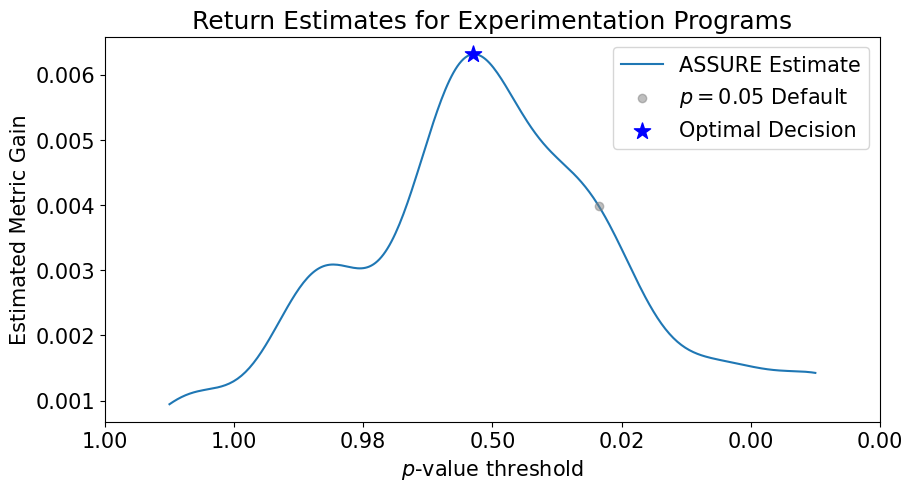

In [ ]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize = (10,5))

from scipy.stats import norm

plt.plot(grid, welfare_estimate, label="ASSURE Estimate", zorder = 0)

# Grey dot at x = Phi^{-1}(0.05)
x = norm.ppf(0.95)
y_val = np.interp(x, grid, welfare_estimate)
plt.scatter(x, y_val, color="grey", label="$p = 0.05$ Default", alpha = 0.5)

# Red star at maximum of the curve
max_idx = np.argmax(welfare_estimate)
plt.scatter(grid[max_idx], welfare_estimate[max_idx], color="blue", marker="*", s=150, label="Optimal Decision")

plt.xlabel("$p$-value threshold")
plt.ylabel("Estimated Metric Gain")
plt.legend()

ticks = plt.xticks()[0]  # current tick locations
tick_labels = [f"{1-norm.cdf(tick):.2f}" for tick in ticks]
plt.xticks(ticks, tick_labels)


plt.title("Return Estimates for Experimentation Programs")
plt.savefig("experimentation_program_welfare_curve.pdf", bbox_inches='tight')

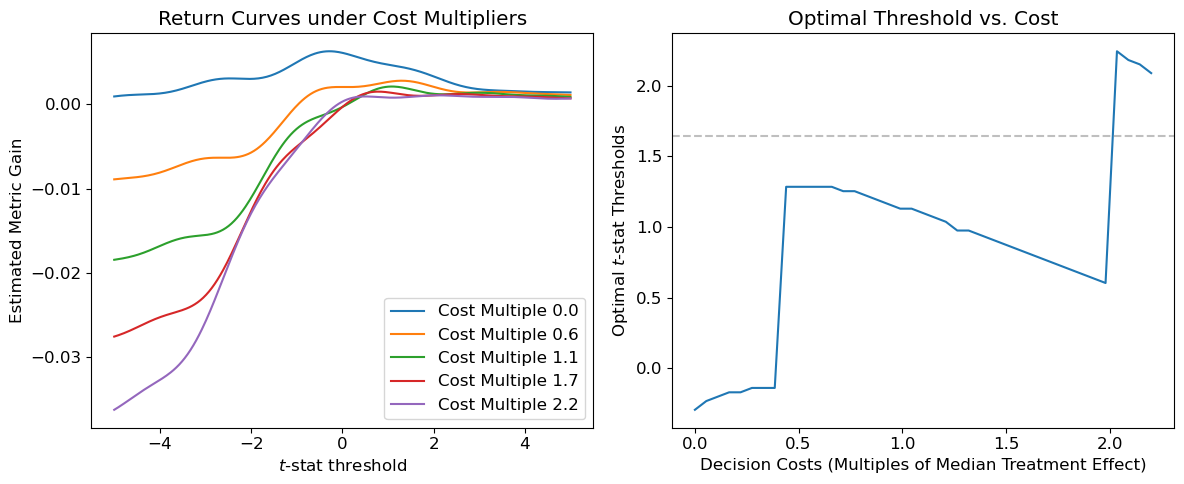

In [16]:
plt.rcParams.update({"font.size":12})

cost_multipliers = np.linspace(0, 2.2, 41)
optimal_thresholds = np.zeros_like(cost_multipliers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left subplot: Welfare estimates for selected cost multipliers ---
for i, kappa in enumerate(cost_multipliers):
    costs = kappa * median_treatment_effect * np.ones(len(Ys))

    welfare_estimate_cost, welfare_se = methods.assure(
        Ys,
        sigmas,
        lambda params: methods.t_stat_threshold_fn(params,
                                                    sigmas=sigmas,
                                                    costs=costs),
        grid.reshape(-1,1),
        costs=costs,
    )

    opt_pvalue = grid[np.argmax(welfare_estimate_cost)]
    optimal_thresholds[i] = opt_pvalue

    if i % 10 == 0:  # only plot every 5th curve
        ax1.plot(grid, welfare_estimate_cost, label=f"Cost Multiple {kappa:.1f}")

ax1.set_xlabel("$t$-stat threshold")
ax1.set_ylabel("Estimated Metric Gain")
ax1.legend()
ax1.set_title("Return Curves under Cost Multipliers")

# --- Right subplot: Optimal thresholds vs cost ---
ax2.plot(cost_multipliers, optimal_thresholds)
ax2.set_xlabel("Decision Costs (Multiples of Median Treatment Effect)")
ax2.set_ylabel("Optimal $t$-stat Thresholds")
ax2.set_title("Optimal Threshold vs. Cost")

# Reference line at p = 2
ax2.axhline(y=norm(0,1).ppf(0.95), linestyle="dashed", alpha=0.5, color="grey")

plt.tight_layout()
plt.savefig("experimentation_program_welfare_costs.pdf", bbox_inches="tight")
plt.show()
